In [236]:
import numpy as np
import matplotlib.pyplot as plt

# Método de bisección

Este método de busqueda por bisección es utilizado para encontrar raíces de una
función continua de variable real. La única condición es que la función cambie de
signo en el intervalo en que buscamos. La existencia de la raíz de la función está
garantizada de acuerdo al teorema de Bolzano:

> <b>Teorema de Bolzano </b>: 
Si $f : [a, b] \to \mathbb{R}$, es una función continua en $[a, b]$ y $f(a)f(b) < 0$, entonces
existe $x_0 \in  [a, b]$ tal que $f(x_0) = 0$.

El método consiste en bisecar el intervalo $[a, b]$, estudiar los signos de $f$ en los
extremos de los nuevos intervalos de manera que podamos afirmar la existencia de
una raíz en un intervalo más pequeño como consecuencia del teorema de Bolzano.

## Algoritmo

Datos de entrada: $a, b,$ función, tolerancia.

calcular $x_0 =\dfrac{a+b}{2}$

Para $i = 0,1,2, ...$ 

* Si $f(a)f(x_i) < 0$, entonces $b = x_i$
* Si $f(a)f(x_i) > 0$, entonces $a = x_i$
* Si $f(a)f(x_i) = 0$, entonces $x_{i+1} = x_{i}$

Hasta que $|x_{i+1}-x_{i}|< tolerancia$. Así entonces si elaboramos una función en `Python` que permita encontrar una aproximación de una raíz de una función $f:[a,b] \to \mathbb{R}$ usando el método de bisección, considerando como datos de entrada una función, $a,b$ y la tolerancia, tendremos:

In [237]:
#como parametros de entrada se tiene el intervalo [a,b], la función f y la tolerancia t

def metodo_biseccion(a,b,f,t): #definimos la función
    if f(a)*f(b)>= 0:
        print("El método de bisección no puede aplicarse si no hay cambio de signo.")
        return None
    x0=(a+b)/2
    while abs(b-a)>t:
        if f(a)*f(x0)<0:
            b=x0
        else:
            a=x0
        x0=(a+b)/2
    return x0

### Ejemplo 01:
Utilice la función anterior y el teorema de Bolzano para encontrar las cuatro raíces de $f(x)=10x^3-2x^2+1-e^{2x}$. Hint: las raíces se encuentran en el intervalo $[-1,3]$.

#### Solución:

Antes de empezar, de acuerdo con el teorema de Bolsano, debemos establecer los intervalos para encontrar las raíces, para ello graficamos en el intervalo que nos señalan en el enunciado:

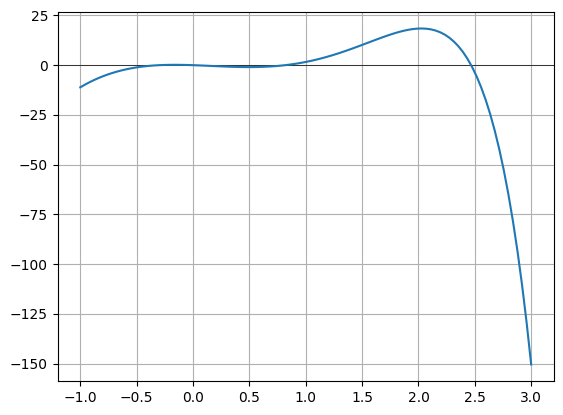

In [238]:
#primero definimos la función
def f(x): return 10*x**3-2*x**2+1-np.exp(2*x)

#ahora hacemos el gráfico:
x=np.linspace(-1,3,100)
y=f(x)
plt.axhline(0, color='black', linewidth=0.5)
plt.plot(x,y)
plt.grid()

El gráfico no nos entrega mucha información, por tanto debemos acotar los intervalos de nuestros gráficos para avanzar en el estudio de las raíces de esta función:

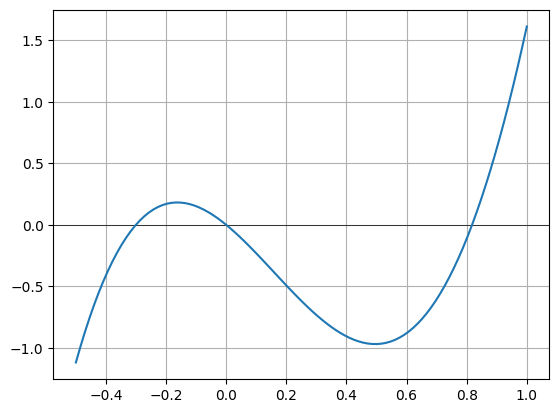

In [239]:
x=np.linspace(-0.5,1,100)
plt.axhline(0, color='black', linewidth=0.5)
y=f(x)
plt.plot(x,y)
plt.grid()

In [240]:
metodo_biseccion(-1,1/4,f,10**(-10))

El método de bisección no puede aplicarse si no hay cambio de signo.


In [241]:
#primera raíz:
metodo_biseccion(-0.4,-0.2,f,0.00001)

-0.30042419433593753

In [242]:
#segunda raíz:
metodo_biseccion(-0.1,0.2,f,0.00001)

-1.52587890625e-06

In [243]:
#tercera raíz:
metodo_biseccion(0.6,1,f,0.00001)

0.8179107666015626

In [244]:
#cuarta raíz:
metodo_biseccion(2,3,f,0.00001)

2.467357635498047

# Método de Newtwon Raphson

Este método es uno de los más populares para encontrar los ceros de una función, pero
requiere del conocimiento de su derivada. La regla principal del algoritmo consiste
en que, dado un punto $x_k$ cercano a la raíz de $f$, se determina la recta tangente a $f$
en $(x_k, f(x_k))$: <br>

$$y = f(x_k) + f'(x_k)(x - x_k)$$

Luego, se define la iteración siguiente $x_{k+1}$ como el punto de intersección entre esa
recta y el eje $x$, es decir, $x_{k+1}$ se obtiene al despejar

$$0 = f(x_k) + f(x_k)(x_{k+1} - x_k)$$

esto es
$$ x_{k+1} = x_k - \dfrac{f(x_k)}{f'(x_k)}  $$ 

<table><tr>
<td> <img src="NewtonIteration_Ani.gif" alt="Drawing" style="width: 512px;"/> </td>
</tr></table>

## Algoritmo

Datos de entrada: $x_0, f , tolerancia$

Para $k = 0, 1, 2, ...$

* calcular $x_{k+1} = x_k - \dfrac{f(x_k)}{f'(x_k)}$

Hasta que $| x_{k+1} - x_k | < tolerancia$

### Ejemplo 01

Elabore una función en Python que permita encontrar una aproximación de una raíz de una función $f:[a,b] \to \mathbb{R}$ usando el método de Newton-Raphson, considerando como datos de entrada un valor cercano a la raíz $x_0$, la función en cuestión $f$, su derivada $df$ y la tolerancia $t$.


In [245]:
import numpy as np
#El metodo funciona de la siguiente forma:
# 1. Se define la función f(x) y su derivada df(x)
# 2. Se define el punto inicial x0
# 3. Se define la tolerancia t
# 4. Se llama a la función newton_raphson(x0,f,df,t)
# 5. Se obtiene la raíz de la función f(x)

def newton_raphson(x0,f,df,t):
    X=[x0]
    while True:
        xn=X[-1]-(f(X[-1])/df(X[-1]))
        X.append(xn)
        if np.abs(X[-1]-X[-2])<t:
            break
    return X[-1]

### Ejemplo 02

Encontrar una aproximación de las raíces de la función $f(x) = x^4-2$ cercana a $x_0=4$ con una tolerancia de $0,000001$.

In [246]:
def f(x): return x**4-2
def df(x): return 4*x**3
newton_raphson(4,f,df,0.000001)
#desafío, comprobar

1.189207115002721

## Ejercicios:
### Ejercicio 01

La ecuación $\ln(2x) = \dfrac{x}{2}$ tiene dos soluciones. Utilice el método de la bisección con un error máximo de $10^{-8}$ para estimar las soluciones de la ecuación. Justifique su razonamiento para aplicar el método:

   * Formulación de la función a utilizar.
   * Elección de intervalo.
   * Elección de la tolerancia.

In [247]:
# Definimos la función
def f(x):
    return np.log(2*x) - x/2

In [248]:
# Se eligen intervalos siempre y cuando se produzca un cambio de signo

# Elegimos el intervalo y la tolerancia
a, b = 0.1, 2  # Elegimos un intervalo donde la función cambia de signo
tolerancia = 1e-8

# Aplicamos el método de bisección
raiz1 = metodo_biseccion(a, b, f, tolerancia)
print(f'Primera raíz: {raiz1}')

# Para encontrar la segunda raíz, elegimos otro intervalo
a, b = 2, 5  # Elegimos un intervalo donde la función cambia de signo
raiz2 = metodo_biseccion(a, b, f, tolerancia)
print(f'Segunda raíz: {raiz2}')

Primera raíz: 0.7148059116676451
Segunda raíz: 4.306584727950394


In [249]:
f(raiz1)

np.float64(-6.249112338707619e-10)

In [250]:
f(raiz2)

np.float64(7.238698529477006e-11)

### Ejercicio 02:

Encontrar utilizando el método de bisección una aproximación de $\sqrt[3]{5}$.

In [ ]:
Para elegir la función a usar en un método numérico como el de bisección o Newton-Raphson, debes seguir estos pasos:

1. **Definir el problema**: Identifica la ecuación o función cuyo cero (raíz) deseas encontrar. La función debe estar bien definida en el intervalo de interés.

2. **Continuidad y derivabilidad**:
    - Para el método de bisección, la función debe ser continua en el intervalo \([a, b]\) y debe cambiar de signo en los extremos del intervalo, es decir, \(f(a) \cdot f(b) < 0\).
    - Para el método de Newton-Raphson, la función debe ser diferenciable en el intervalo de interés, y su derivada no debe ser cero en el punto inicial.

3. **Intervalo de interés**:
    - Para el método de bisección, elige un intervalo \([a, b]\) donde la función cambie de signo.
    - Para el método de Newton-Raphson, elige un punto inicial \(x_0\) cercano a la raíz esperada.

4. **Tolerancia**: Define una tolerancia \(t\) que determine la precisión de la solución. La iteración continuará hasta que la diferencia entre dos iteraciones consecutivas sea menor que esta tolerancia.

5. **Formulación de la función**: Escribe la función \(f(x)\) y, si usas Newton-Raphson, también su derivada \(f'(x)\).

Por ejemplo, para encontrar las raíces de la ecuación \(\ln(2x) = \frac{x}{2}\):

1. **Definir el problema**: Queremos encontrar \(x\) tal que \(\ln(2x) = \frac{x}{2}\).
2. **Reformular la ecuación**: Define la función \(f(x) = \ln(2x) - \frac{x}{2}\).
3. **Intervalo de interés**: Elige intervalos donde la función cambie de signo para el método de bisección, o puntos iniciales cercanos a las raíces esperadas para Newton-Raphson.
4. **Tolerancia**: Define una tolerancia, por ejemplo, \(10^{-8}\).
5. **Formulación de la función**:
    ```python
    def f(x):
         return np.log(2*x) - x/2

    def df(x):
         return 1/(2*x) - 1/2
    ```

Con esta lógica, puedes aplicar el método de bisección o Newton-Raphson para encontrar las raíces de la función.

In [251]:
# Definimos la función
def f(x):
    return x**3 - 5

# Elegimos el intervalo y la tolerancia
a = 0
b = 2  # Elegimos un intervalo donde la función cambia de signo
tolerancia = 10**-8

# Aplicamos el método de bisección
raiz = metodo_biseccion(a, b, f, tolerancia)
print(f'La aproximación de la raíz cúbica de 5 es: {raiz}')

La aproximación de la raíz cúbica de 5 es: 1.7099759466946125


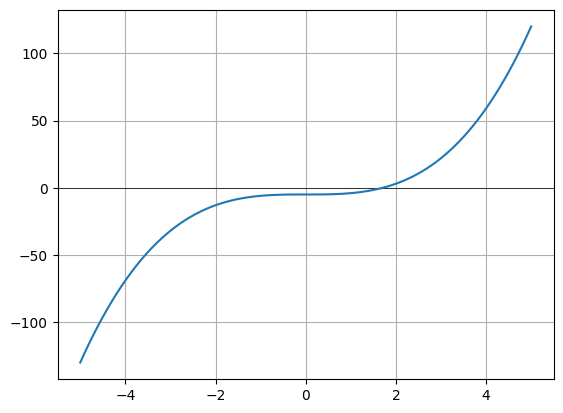

In [252]:
#ahora hacemos el gráfico:
x=np.linspace(-5,5,100)
y=f(x)
plt.axhline(0, color='black', linewidth=0.5)
plt.plot(x,y)
plt.grid()

### Ejercicio 03                                     

Utilice e método de Newton-Raphson para encontrar las cuatro raíces de $f(x)=10x^3-2x^2+1-e^{2x}$. Ayuda: las raíces se encuentran en el intervalo $[-1,3]$.

In [253]:
# Definimos la función y su derivada
def f(x): return 10*x**3 - 2*x**2 + 1 - np.exp(2*x)
def df(x): return 30*x**2 - 4*x - 2*np.exp(2*x)

# Elegimos los puntos iniciales cercanos a las raíces y la tolerancia
x0_values = [-0.5, 0.1, 0.8, 2.5]
tolerancia = 1e-8

# Aplicamos el método de Newton-Raphson para cada punto inicial
raices = [newton_raphson(x0, f, df, tolerancia) for x0 in x0_values]
print(f'Las raíces aproximadas son: {raices}')

Las raíces aproximadas son: [np.float64(-0.30042328202638807), np.float64(8.527471109322064e-18), np.float64(0.8179087029436929), np.float64(2.4673563603513617)]


### Ejercicio 04

La ecuación $\ln(2x) = \dfrac{x}{2}$ tiene dos soluciones. Utilice el método de Newton-Raphson con un error máximo de $10^{-8}$ para estimar las soluciones de la ecuación. Justifique su razonamiento para aplicar el método:

   * Formulación de la función a utilizar.
   * Elección de intervalo.
   * Elección de la tolerancia.

In [254]:
# Definimos la función y su derivada
def f(x):
    return np.log(2*x) - x/2

def df(x):
    return 1/x - 1/2

# Elegimos los puntos iniciales cercanos a las raíces y la tolerancia
x0_values = [0.5, 3.0]
tolerancia = 1e-8

# Aplicamos el método de Newton-Raphson para cada punto inicial
raices = [newton_raphson(x0, f, df, tolerancia) for x0 in x0_values]
print(f'Las raíces aproximadas son: {raices}')


Las raíces aproximadas son: [np.float64(0.7148059123627778), np.float64(4.3065847282207)]


### Ejercicio 05*:

Encuentre la solución(es) a la ecuación:
$$\dfrac{1}{1-x}=e^x$$
en el intervalo $[-0.5,\, 1]$ mediante el método de Newton-Raphson, si es posible. En caso contrario, justifique.


### Ejercicio 06

Encontrar utilizando el método de Newton-Raphson una aproximación de $\sqrt[3]{7}$.

### Ejercicio 07

Una canaleta  de largo $L$ tiene por sección tranversal forma de semicircunferencia de radio $r$ (ambos medidos en cm), como muestra la figura a contianuación:

<table><tr>
<td> <img src="C1.png" alt="Drawing" style="width: 250px;"/> </td>
<td> <img src="C2.png" alt="Drawing" style="width: 250px;"/> </td>
</tr></table>

Cuando se llena de agua hasta una distancia $h$ de su parte superior, el volumen $V$ de agua es

$$V=L\left[ \frac{1}{2}\pi r^2 - r^2\arcsin\left(\frac{h}{r} \right) - h\sqrt{r^2-h^2} \right]$$

Suponga que el $L=300 [m]$, $r=30 [cm]$ y el volumen de agua es $V=216 [cm^3]$. Encuentre una aproximación de la altura del agua desde la base de la canaleta.


### Ejercicio 08

Encontrar una aproximación de el (los) punto(s) de intersección de las curvas $y=e^x$ e $y=x^2$, utilizando el método de Newton-Raphson.

### Ejercicio 09

Encontrar una aproximación de la raíz de la función $h(x) = e^x + 2$ cercana a $x_0 = 2$ con una tolerancia de $0,01.$ Use ambos métodos.

### Ejercicio 10

Encontrar una aproximación de $\sqrt{3}$. Use ambos métodos.